# PyWaffle

Waffle charts for matplotlib — also known as square pie charts, and, when drawn with icons,
pictogram charts.

This notebook is runnable. On [Binder](https://mybinder.org/v2/gh/gyli/PyWaffle/master?filepath=demo.ipynb)
it runs against **this repository's** code; run it locally and it installs the released version from
PyPI if you do not already have it.

Documentation: <https://pywaffle.readthedocs.io/>

In [1]:
# On Binder, PyWaffle is already installed from this repository, so this does nothing.
# Elsewhere, it installs the released version.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pywaffle") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pywaffle"])

import matplotlib.pyplot as plt

from pywaffle import Waffle

print("PyWaffle", __import__("pywaffle").__version__)

PyWaffle 1.2.0


## 1. A basic chart

`Waffle` is a matplotlib [Figure class](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/custom_figure_class.html),
so you pass it to `plt.figure` and get back an ordinary matplotlib figure.

Give it `rows` and `columns` and the values are scaled to fit the grid.

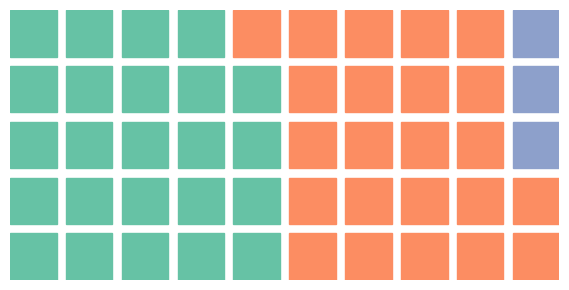

In [2]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values=[48, 46, 6],
    figsize=(6, 3),
)
plt.show()

## 2. Labels, and showing the numbers

Pass a dict and the keys become the labels. `show_values` puts each category's number next to its
name, so you do not have to build the label strings yourself.

Use `show_values='percentage'` for each category's share of the total, and `value_format` to
control how the number is written.

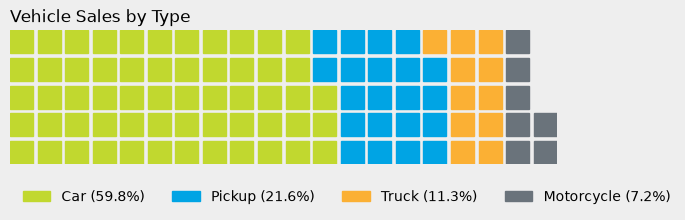

In [3]:
data = {"Car": 58, "Pickup": 21, "Truck": 11, "Motorcycle": 7}

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=data,
    colors=["#c1d82f", "#00a4e4", "#fbb034", "#6a737b"],
    title={"label": "Vehicle Sales by Type", "loc": "left"},
    show_values="percentage",
    legend={"loc": "lower left", "bbox_to_anchor": (0, -0.4), "ncol": len(data), "framealpha": 0},
    figsize=(7, 3),
)
fig.set_facecolor("#EEEEEE")
plt.show()

## 3. Pictogram charts

Pass `icons` to draw [Font Awesome](https://fontawesome.com/icons) glyphs instead of squares.
A single name applies to every category, or give one per category.

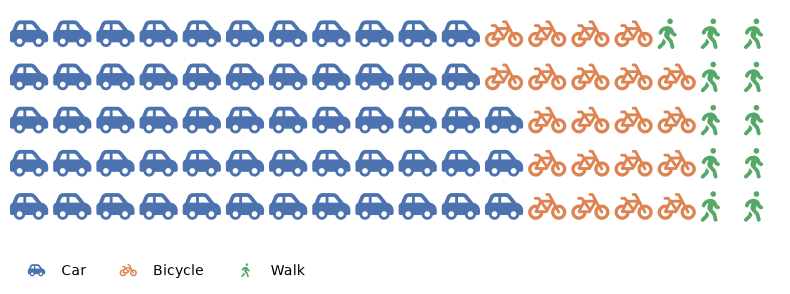

In [4]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values={"Car": 58, "Bicycle": 21, "Walk": 11},
    icons=["car-side", "bicycle", "person-walking"],
    icon_legend=True,
    font_size=22,
    colors=["#4c72b0", "#dd8452", "#55a868"],
    legend={"loc": "lower left", "bbox_to_anchor": (0, -0.35), "ncol": 3, "framealpha": 0},
    figsize=(8, 3),
)
plt.show()

## 4. Fractional blocks

By default every value is rounded to a whole block. `rounding_rule='float'` stops rounding: a
category that ends part way through a block fills only that fraction, and a block containing a
boundary between two categories is split between their colours.

The useful consequence is that the number of blocks depends only on the **total**, so two datasets
with the same total always produce charts of the same size.

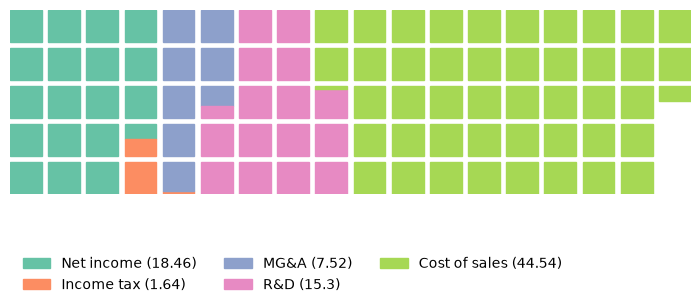

In [5]:
budget = {"Net income": 18.46, "Income tax": 1.64, "MG&A": 7.52, "R&D": 15.3, "Cost of sales": 44.54}

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=budget,
    rounding_rule="float",
    block_arranging_style="snake",
    show_values=True,
    legend={"loc": "lower left", "bbox_to_anchor": (0, -0.6), "ncol": 3, "framealpha": 0},
    figsize=(9, 3),
)
plt.show()

## 5. pandas, and sorting

A pandas Series works directly — its index becomes the labels, just as a dict's keys do.
`sort_values=True` orders the categories largest first, carrying each category's colour and label
along with it.

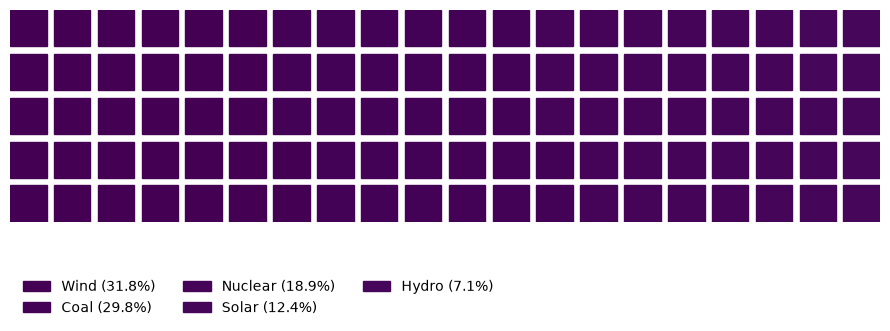

In [6]:
import pandas as pd

series = pd.Series({"Solar": 12.4, "Wind": 31.8, "Hydro": 7.1, "Nuclear": 18.9, "Coal": 29.8})

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=20,
    values=series,
    sort_values=True,
    show_values="percentage",
    cmap_name="viridis",
    legend={"loc": "lower left", "bbox_to_anchor": (0, -0.5), "ncol": 3, "framealpha": 0},
    figsize=(9, 3),
)
plt.show()

## 6. Several charts in one figure

`plots` takes a dict of subplot position to arguments. Anything set at the figure level is
inherited by each subplot unless it overrides it.

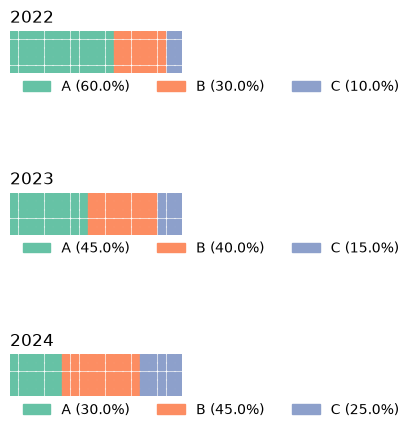

In [7]:
fig = plt.figure(
    FigureClass=Waffle,
    plots={
        311: {"values": {"A": 60, "B": 30, "C": 10}, "title": {"label": "2022", "loc": "left"}},
        312: {"values": {"A": 45, "B": 40, "C": 15}, "title": {"label": "2023", "loc": "left"}},
        313: {"values": {"A": 30, "B": 45, "C": 25}, "title": {"label": "2024", "loc": "left"}},
    },
    rows=5,
    columns=20,
    show_values="percentage",
    legend={"loc": "lower left", "bbox_to_anchor": (0, -0.8), "ncol": 3, "framealpha": 0},
    figsize=(9, 5),
)
plt.show()

## 7. Into an axes you already have

`Waffle.make_waffle` draws into an existing axes, so a waffle can sit alongside other plots in a
layout you built yourself.

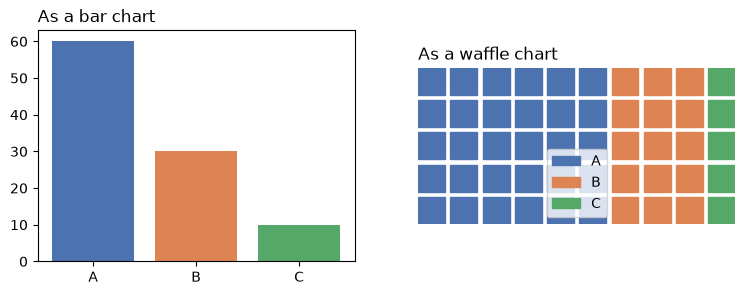

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].bar(["A", "B", "C"], [60, 30, 10], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("As a bar chart", loc="left")

axes[1].set_aspect("equal")
Waffle.make_waffle(
    ax=axes[1],
    rows=5,
    columns=10,
    values={"A": 60, "B": 30, "C": 10},
    colors=["#4c72b0", "#dd8452", "#55a868"],
    title={"label": "As a waffle chart", "loc": "left"},
)
plt.show()

## Where next

- [Documentation](https://pywaffle.readthedocs.io/) — every parameter, with examples
- [API reference](https://pywaffle.readthedocs.io/en/latest/class.html)
- [GitHub](https://github.com/gyli/PyWaffle) — issues and pull requests welcome